# Ticket: Feature Selection & Deny List Policy
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU
Notebook này chọn lọc danh sách đặc trưng chính thức (`selected_features.json`) an toàn để đưa vào huấn luyện mô hình Machine Learning:

1. **Thiết lập Danh sách Cấm (Deny List)**: Loại bỏ triệt để các cột gây rò rỉ nhãn (Target Leakage), cột ID, cột thông tin tương lai không tồn tại lúc inference.
2. **Lọc dòng hợp lệ (Clean Subset)**: Chỉ chấm điểm đặc trưng trên các dòng có `exclude_from_training == False` để tránh dữ liệu chèn hoặc ô nhiễm làm bóp méo điểm số.
3. **Chấm điểm đặc trưng (Mutual Information)**: Sử dụng thuật toán `sklearn.feature_selection.mutual_info_regression` để đánh giá mối quan hệ phi tuyến giữa từng đặc trưng và target (`energy_generated_kwh`).
4. **Đối chiếu VIF & Xuất danh sách Top Features**: Kết hợp với bảng chẩn đoán VIF ở Notebook 06 để xuất danh sách Top 35 đặc trưng tối ưu nhất.

**Input:**
- `../../data/model/v5/03_3_features_aggregate/v5_train_features.parquet`
- `../../data/model/v5/04_diagnostics/feature_diagnostics.csv` (Output từ Notebook 06)

**Output:**
- `../../data/model/v5/05_selected/selected_features.json`
- `../../data/model/v5/05_selected/feature_scores.csv`

**Nguồn logic tham chiếu Audit:**
- Tham khảo ý tưởng từ `srcs/05_machine_learning/Forcasting_v3/07_select_features_sklearn.py` (viết lại 100% bằng Pandas & Sklearn thuần).


## 2. Import thư viện và khai báo tham số
*Nguồn tham chiếu logic:* N/A (Setup chung)

In [2]:
# ── Gioi han thread: may i5-12450HX co 8 core / 12 thread (4 P-core + 4 E-core).
# Dung het 12 thread lam cac thread tranh nhau va CHAM HON. Dat 6 de bam P-core,
# con lai de cho Jupyter va he dieu hanh. Phai set TRUOC khi numpy nap moi co tac dung.
import os

for _bien in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
              'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_bien, '6')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ── Tham số chung ──
VERSION = "v5"
SITE_COL = "site_id"
TIMESTAMP_COL = "timestamp"
TARGET_COL = "energy_generated_kwh"

# ── Tham số pipeline ──
MI_SAMPLE_SIZE = 100000        # Lấy sample 100,000 dòng hợp lệ để tính Mutual Info
TOP_K_FEATURES = 35           # Số lượng feature tối ưu chọn ra
RANDOM_STATE = 42

# ── Đường dẫn Input / Output (tương đối) ──
TRAIN_INPUT = "../../data/model/v5/03_3_features_aggregate/v5_train_features.parquet"
DIAGNOSTICS_INPUT = "../../data/model/v5/04_diagnostics/feature_diagnostics.csv"

JSON_OUTPUT = "../../data/model/v5/05_selected/selected_features.json"
CSV_OUTPUT = "../../data/model/v5/05_selected/feature_scores.csv"

print("Đã import thư viện và khai báo tham số.")
print(f"- Sample size Mutual Information: {MI_SAMPLE_SIZE}")
print(f"- Top K features sẽ chọn: {TOP_K_FEATURES}")
print(f"- Train input: {TRAIN_INPUT}")
print(f"- Output JSON: {JSON_OUTPUT}")


Đã import thư viện và khai báo tham số.
- Sample size Mutual Information: 100000
- Top K features sẽ chọn: 35
- Train input: ../../data/model/v5/03_3_features_aggregate/v5_train_features.parquet
- Output JSON: ../../data/model/v5/05_selected/selected_features.json


## 3. Đọc train_agg và bảng chẩn đoán từ notebook 06
Đọc tập dữ liệu `train_agg.parquet` từ Notebook 05 và bảng chẩn đoán `feature_diagnostics.csv` từ Notebook 06.

In [3]:
df_train = pd.read_parquet(TRAIN_INPUT)
df_diag = pd.read_csv(DIAGNOSTICS_INPUT)

print(f"Đã đọc train_agg: {len(df_train)} dòng x {len(df_train.columns)} cột")
print(f"Đã đọc bảng chẩn đoán: {len(df_diag)} đặc trưng")
print("Sample Bảng Chẩn đoán:")
display(df_diag.head(3))

Đã đọc train_agg: 1550856 dòng x 113 cột
Đã đọc bảng chẩn đoán: 85 đặc trưng
Sample Bảng Chẩn đoán:


,feature,dtype,nan_pct,nunique,variance,duplicate_of,vif,flag,pls_vip
0,year,float32,2.32,2,0.246623,NaN,2.37,OK,0.059
1,month,float32,0.00,12,11.634602,NaN,5170.17,HIGH_VIF,0.047
2,day,float32,2.32,31,75.371450,NaN,27.34,HIGH_VIF,0.021


## 4. Danh sách cấm (Deny List) và lý do
Bảo vệ mô hình khỏi **Rò rỉ Nhãn (Target Leakage)** và **Độ nhiễu thực tế (Inference Gap)**. Các nhóm cột sau bị cấm tuyệt đối:

In [4]:
# DENY LIST CỐ ĐỊNH
DENY_TARGET = ['energy_generated_kwh', 'y_muc_tieu']

DENY_PROVENANCE_OUTLIER = [
    'gmm_if_outlier_flag', 'gmm_if_outlier_reason', 'outlier_group',
    'exclude_from_training', 'exclude_reason', 'training_quality_reason',
    'energy_source', 'timestamp_was_inserted', 'source_gap_id',
    'after_source_gap_steps_remaining'
]

DENY_DAYLIGHT_AUDIT = [
    'is_daylight', 'weather_is_day', 'sunshine_duration', 'weather_is_observed'
]

DENY_IDS = [
    'gen_id', 'site_id', 'geo_id', 'date_id', 'time_id', 'weather_id', 'weather_type_id'
]

DENY_RAW_CATEGORICAL = [
    'site_id', 'campus_name', 'location_name', 'site_metric', 'panel',
    'inverter', 'optimizers', 'weather_join_method',
    'weather_condition', 'weather_description'
]
# Các cột này đã được mã hóa thành *_enc ở notebook 03_3; giữ bản thô vừa trùng thông tin vừa không ép được về số.

DENY_RAW_TIME = ['timestamp', 'time_diff', 'full_date', 'weather_timestamp', 'year']
# 'year' bi cam vi TANG DON DIEU, khong tuan hoan:
#   train year = {2020, 2021} | test year = {2021, 2022}
#   -> 455.616 dong test (89%) co year = 2022 chua TUNG xuat hien luc train.
#   Cay quyet dinh tach theo 'year <= 2021' se ap quy tac hoc tu gia tri chua he thay.
#   Khac voi month / day_of_year / doy_sin / doy_cos: nhung cai do TUAN HOAN, lap lai hang nam.
# Bat moi cot con lai co chua 'timestamp' trong ten: thoi gian tho tang don dieu,
# model se hoc theo do lon cua timestamp va khong the ngoai suy sang tuong lai
# (moi timestamp tuong lai deu lon hon toan bo tap train).


DENY_STRUCTURAL_COLLINEAR = [
    'dni_ratio', 'con_cach_tran', 'site_scale', 'pv_clr_lonij', 'clearsky_proxy'
]
# dni_ratio = 1 - diffuse_ratio theo dinh nghia vat ly (GHI = diffuse + direct),
#   nen dni_ratio va diffuse_ratio la dang thuc tuyen tinh chinh xac, khong phai
#   trung lap ngau nhien. VIF o notebook 04 khong bat duoc vi nguong DUP_THRESHOLD=0.9999
#   tinh tren toan bo du lieu (bao gom dem NaN lam loang r), nhung VIF tren sample daytime
#   van no vo cuc. Giu diffuse_ratio (y nghia vat ly ro: ty le may mu), bo dni_ratio.
# con_cach_tran = tran_cong_suat - ky_vong: to hop tuyen tinh chinh xac cua 2 cot con lai
#   trong nhom (03_2), khong mang thong tin moi ngoai 2 cot do cong lai.
# clearsky_proxy = sin_elevation ** 1.2 (DA XOA noi sinh o 03_2 ngay 2026-08-20;
#   giu ten trong DENY lam ho so va phong file trung gian cu). Tren mien [0; 0,9824] cua sin_elevation, ham x**1.2
#   don dieu tang nghiem ngat -> do bang Spearman = 1,0000000000, 0/1.514.911 cap vi pham.
#   Mo hinh cay chia theo nguong nen chia tren x**1.2 tuong duong hoan toan voi chia tren x:
#   khi sin_elevation da co san thi cot nay mang DUNG BANG KHONG thong tin moi. Bang chan doan
#   xac nhan: PLS VIP 1,291 so voi 1,293 cua sin_elevation, VIF 1050. So mu 1.2 cung khong co
#   xuat xu nao trong tai lieu -> bo han thay vi bia ly do.
# pv_clr_lonij la MAU SO chuan hoa muc tieu theo Lonij et al. (2012). Giu lai trong du lieu
#   de nhan nguoc khi cham diem, nhung KHONG duoc lam dau vao mo hinh - dua vao thi mo hinh
#   co san thang do cua chinh muc tieu, y het ly do da cam site_scale.
# site_scale va tran_cong_suat deu la hang so theo site (phan vi 99 va 99,9 cua cung
#   phan phoi san luong) nen tuong quan gan nhu tuyet doi qua cac site; giu tran_cong_suat
#   (dang duoc dung truc tiep trong ty_le_bao_hoa/con_cach_tran), bo site_scale khoi feature train.
# Tổng hợp Deny List đầy đủ
DENY_LIST = set(
    DENY_TARGET + DENY_PROVENANCE_OUTLIER + DENY_DAYLIGHT_AUDIT +
    DENY_IDS + DENY_RAW_TIME + DENY_RAW_CATEGORICAL + DENY_STRUCTURAL_COLLINEAR
)

# Lọc bỏ thêm tất cả các cột split metadata (bắt đầu bằng v5_)
all_cols = set(df_train.columns)
v5_cols = {c for c in all_cols if c.startswith('v5_')}
# Bo dac trung moi dung tien to v5_ cho CHINH cac cot dac trung, nen KHONG the cam ca 'v5_'.
# Chi cam cac cot metadata cua buoc split (do notebook 02 gan).
SPLIT_META = ['v5_holdout_split','v5_test_start_timestamp','v5_split_strategy',
              'v5_n_time_series_splits','v5_split','v5_cv_fold','v5_cv_role']
DENY_LIST.update([c for c in SPLIT_META if c in df_train.columns])

# Danh sách candidate features thực sự an toàn
DENY_LIST.update([c for c in df_train.columns if 'timestamp' in c.lower()])

# Bo cac dac trung da bi notebook 06 gan co DUPLICATE (cong tuyen hoan hao):
# trong nhom trung lap chung mang dung cung mot thong tin, giu nhieu ban chi lam
# loang diem Mutual Information va loang feature importance cua LightGBM.
dup_cols = set(df_diag.loc[df_diag['duplicate_of'].notna(), 'feature']) \
    if 'duplicate_of' in df_diag.columns else set()
DENY_LIST.update(dup_cols)
print(f"So dac trung bi bo do trung lap (tu notebook 06): {len(dup_cols)}")

candidate_features = [c for c in df_train.columns if c not in DENY_LIST]

print(f"Tổng số cột ban đầu: {len(df_train.columns)}")
print(f"Số cột nằm trong Deny List (bị cấm): {len(DENY_LIST)}")
print(f"Số cột ứng viên an toàn còn lại: {len(candidate_features)}")
print("Sample candidate features:")
print(candidate_features[:10])


So dac trung bi bo do trung lap (tu notebook 06): 8
Tổng số cột ban đầu: 113
Số cột nằm trong Deny List (bị cấm): 54
Số cột ứng viên an toàn còn lại: 74
Sample candidate features:
['month', 'day', 'day_of_week', 'hour', 'minute', 'capacity_kw', 'number_of_panels', 'latitude', 'longitude', 'shortwave_radiation']


### Nhận xét: Lý do tại sao phải cấm các nhóm cột này (Bằng chứng từ dữ liệu thô):

1. **Nhóm Cột Provenance/Outlier (`exclude_from_training`, `outlier_group`, `energy_source`)**:
   - Bằng chứng 1: Khi `exclude_from_training == True`, sản lượng `energy_generated_kwh` bằng `0.0` ở **100.00% trường hợp** (36,847 dòng trong tập train). Các dòng này bị gán `machine_failure_zero` do gap lớn >= 24h.
   - Bằng chứng 2: Nhóm `outlier_group == physical_over_capacity` có sản lượng trung bình đạt **19.43 kWh**, vượt xa nhóm `normal` (**2.75 kWh**).
   - **Hậu quả Rò rỉ Nhãn**: Các cột này được tạo ra **SAU KHI** đã đo và kiểm tra sản lượng target. Nếu đưa vào mô hình, mô hình chỉ cần tra bảng "nếu thấy cờ thì đoán 0", dẫn đến điểm số R2/RMSE cực cao trên tập train/val nhưng **HOÀN TOÀN THẤT BẠI KHI DỰ BÁO TƯƠNG LAI** (vì thời điểm tương lai chưa có dữ liệu đo để gán cờ).
   - **Vai trò đúng của 5 cột outlier/provenance**: Chỉ được dùng để: (1) lọc dòng khỏi tập train, (2) gán trọng số mẫu (sample weights), (3) khoanh vùng tính toán metric theo nhóm.

2. **Nhóm Cột ID và Metadata Split (`v5_`)**:
   - Tránh việc mô hình học vẹt (memorize) index hoặc thông tin tĩnh theo từng trạm cụ thể thay vì học đặc tính vật lý thời tiết.

3. **Nhóm Cột Thời gian thô (`timestamp`, `full_date`)**:
   - Chuỗi timestamp tăng dần theo thời gian không thể đưa trực tiếp vào thuật toán cây. Đã được mã hóa thành các đặc trưng chu kỳ `hour_sin/cos`, `doy_sin/cos` và `season_encoded`.

## 5. Lọc dòng hợp lệ để chấm điểm
Chỉ thực hiện chấm điểm đặc trưng trên tập dữ liệu sạch (`exclude_from_training == False`).

In [5]:
# ── Loc dong hop le + DUNG NHAN TAI T+h (khong phai T) ──────────────────────
# SUA 2026-08-20: truoc day MI duoc cham voi energy_generated_kwh TAI T, trong khi mo
# hinh hoc y(T+h). Hai dai luong tuong quan rat cao o luoi 15 phut nen thu hang gan
# giong nhau, nhung ve nguyen tac phai cham dung muc tieu that su cua bai toan.
# Dung h = 1 (tam chinh); bo dac trung duoc dung chung cho ca h1 va h4.
HORIZON_MI = 1

if 'exclude_from_training' in df_train.columns:
    df_clean = df_train[df_train['exclude_from_training'] == False].copy()
else:
    df_clean = df_train.copy()

# Dich muc tieu len h buoc TRONG TUNG TRAM (khong dich xuyen tram)
df_clean = df_clean.sort_values([SITE_COL, TIMESTAMP_COL])
df_clean['y_muc_tieu'] = df_clean.groupby(SITE_COL)['energy_generated_kwh'].shift(-HORIZON_MI)
_truoc = len(df_clean)
df_clean = df_clean.dropna(subset=['y_muc_tieu'])
print(f"Dich muc tieu sang T+{HORIZON_MI} buoc: bo {_truoc - len(df_clean):,} dong cuoi moi tram")

print(f"Tổng số dòng ban đầu: {len(df_train)}")
print(f"Số dòng hợp lệ (exclude_from_training == False): {len(df_clean)} ({len(df_clean)/len(df_train):.2%})")
print(f"Số dòng bị loại trừ khỏi chấm điểm: {len(df_train) - len(df_clean)}")

Dich muc tieu sang T+1 buoc: bo 42 dong cuoi moi tram
Tổng số dòng ban đầu: 1550856
Số dòng hợp lệ (exclude_from_training == False): 1520073 (98.02%)
Số dòng bị loại trừ khỏi chấm điểm: 30783


## 6. Chấm điểm feature bằng Mutual Information
Sử dụng `sklearn.feature_selection.mutual_info_regression` để tính điểm Mutual Information (MI) giữa từng ứng viên đặc trưng và `energy_generated_kwh`.

**Xử lý cột categorical / object:** Chuyển đổi các cột chuỗi (`season_model`, `season`, v.v.) sang mã số bằng `factorize` hoặc `cat.codes` trước khi đưa vào hàm tính MI.

In [6]:
# Lấy sample 100,000 dòng để tính Mutual Information nhanh chóng
sample_df = df_clean.sample(n=min(MI_SAMPLE_SIZE, len(df_clean)), random_state=RANDOM_STATE).copy()

X_sample = sample_df[candidate_features].copy()
y_sample = sample_df['y_muc_tieu'].values      # nhan tai T+h, khong phai T

# Encode các cột string/categorical sang số bằng factorize
for col in X_sample.columns:
    if not pd.api.types.is_numeric_dtype(X_sample[col]):
        X_sample[col] = pd.factorize(X_sample[col])[0]

# Impute tạm thời median cho NaN trong X_sample
X_sample = X_sample.fillna(X_sample.median())

print(f"Đang tính toán Mutual Information trên sample {len(X_sample)} dòng cho {len(candidate_features)} đặc trưng...")
mi_scores = mutual_info_regression(X_sample.values, y_sample, random_state=RANDOM_STATE)

# Đưa điểm vào DataFrame
df_scores = pd.DataFrame({
    'feature': candidate_features,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("\n--- TOP 15 ĐẶC TRƯNG CÓ ĐIỂM MUTUAL INFORMATION CAO NHẤT ---")
display(df_scores.head(15))

Đang tính toán Mutual Information trên sample 100000 dòng cho 74 đặc trưng...

--- TOP 15 ĐẶC TRƯNG CÓ ĐIỂM MUTUAL INFORMATION CAO NHẤT ---


,feature,mi_score
0,ky_vong,1.077752
1,rolling_max_4,0.973319
2,rolling_mean_4,0.951337
3,rolling_min_4,0.918274
4,lag_96,0.909955
5,solar_elevation,0.826770
6,ghi_cs,0.803824
7,ty_le_bao_hoa,0.799848
8,sin_elevation,0.798900
9,rad_x_sinelev,0.741476


## 7. Đối chiếu điểm MI với VIF từ 
Kết hợp điểm Mutual Information với các chỉ số chẩn đoán ở Notebook 06 (`vif`, `nan_pct`) để xác định đặc trưng có điểm MI cao nhưng đồng thời mang VIF lớn.

In [7]:
# Merge bảng điểm MI với bảng chẩn đoán từ Notebook 06
df_merged = pd.merge(df_scores, df_diag[[c for c in ['feature','vif','nan_pct','flag','duplicate_of'] if c in df_diag.columns]], on='feature', how='left')

# ── Danh sách bảo vệ: đặc trưng bắt buộc phải có, không được cắt bởi Top K ──
# Nhóm điện mặt trời sinh ở notebook 03-2 để khử trễ pha. Mutual Information có thể xếp
# chúng ngoài Top K vì chúng tương quan với nhau, nhưng mô hình cần đủ cả nhóm.
# Xem docs/2026_07_30_Khu_Tre_Pha_Du_Bao_15_Phut.md
BAO_VE = [
    # hinh hoc mat troi va buc xa troi quang
    'solar_elevation', 'solar_azimuth', 'azimuth_sin', 'azimuth_cos',
    'sin_elevation', 'ghi_cs', 'cs_factor', 'rad_x_sinelev',
    # quy mo va tran cong suat tram (site_scale, con_cach_tran bi cam do cong tuyen cau truc,
    # xem DENY_STRUCTURAL_COLLINEAR o buoc 4)
    'tran_cong_suat', 'ky_vong', 'ty_le_bao_hoa',
    # buc xa da downscale, la dau vao chinh
    'shortwave_radiation', 'direct_normal_irradiance', 'diffuse_solar_radiation',
    'temperature_c',
    # lich su 1 ngay, khong gay tre pha
    # rolling_min_96 DA BO khoi danh sach bao ve (2026-08-16): cua so 96 buoc = dung 24 gio
    # nen luon trum qua ban dem, ma ban dem san luong = 0 nen gia tri nho nhat luon bang 0.
    # Cot hang so: phuong sai 0, diem MI 0, notebook 04 gan nhan CONSTANT.
    'lag_96', 'rolling_mean_96', 'rolling_max_96', 'rolling_std_96',
    # mua vu: gio dinh thuc te dich toi ~1,75 tieng giua cac thang (thang 12: 14:30,
    # thang 4: 12:45), khong the giai thich bang rieng goc mat troi (chi lech ~16 phut
    # ca nam theo phuong trinh thoi gian). MI xep hang thap nen bi Top-K cat, phai bao ve.
    'doy_sin', 'doy_cos',
]

_co_bao_ve = [c for c in BAO_VE if c in df_merged['feature'].values]
_thieu_bao_ve = [c for c in BAO_VE if c not in df_merged['feature'].values]

# Chọn Top K features tốt nhất, rồi bổ sung nhóm bảo vệ nếu bị cắt
selected_top_k = df_merged.head(TOP_K_FEATURES).copy()
_da_co = set(selected_top_k['feature'])
_bi_cat = [c for c in _co_bao_ve if c not in _da_co]

if _bi_cat:
    _bu = df_merged[df_merged['feature'].isin(_bi_cat)]
    selected_top_k = pd.concat([selected_top_k, _bu], ignore_index=True)

print("--- DANH SACH BAO VE ---")
print(f"Co trong du lieu   : {len(_co_bao_ve)}/{len(BAO_VE)}")
if _thieu_bao_ve:
    print(f"Khong co, bo qua   : {_thieu_bao_ve}")
    print("   Neu thieu nhom PV thi phai chay lai notebook 03-2 truoc.")
if _bi_cat:
    print(f"Bi Top K cat, da bo sung lai ({len(_bi_cat)}): {_bi_cat}")
else:
    print("Khong co dac trung bao ve nao bi Top K cat.")
print(f"Tong dac trung duoc chon: {TOP_K_FEATURES} (Top K) + {len(_bi_cat)} (bao ve) = {len(selected_top_k)}")

print(f"\n--- BÁO CÁO TOP {TOP_K_FEATURES} ĐẶC TRƯNG ĐƯỢC CHỌN VÀ ĐỐI CHIẾU VIF ---")
display(selected_top_k)


--- DANH SACH BAO VE ---
Co trong du lieu   : 21/21
Bi Top K cat, da bo sung lai (4): ['azimuth_sin', 'temperature_c', 'doy_sin', 'doy_cos']
Tong dac trung duoc chon: 35 (Top K) + 4 (bao ve) = 39

--- BÁO CÁO TOP 35 ĐẶC TRƯNG ĐƯỢC CHỌN VÀ ĐỐI CHIẾU VIF ---


,feature,mi_score,vif,nan_pct,flag,duplicate_of
0,ky_vong,1.077752,21.58,2.32,HIGH_VIF,NaN
1,rolling_max_4,0.973319,1412.58,0.01,HIGH_VIF,NaN
2,rolling_mean_4,0.951337,467.40,0.01,HIGH_VIF,NaN
3,rolling_min_4,0.918274,873.04,0.01,HIGH_VIF,NaN
4,lag_96,0.909955,5.46,0.26,OK,NaN
5,solar_elevation,0.826770,70.41,2.32,HIGH_VIF,NaN
6,ghi_cs,0.803824,299.90,0.00,HIGH_VIF,NaN
7,ty_le_bao_hoa,0.799848,246.34,2.32,HIGH_VIF,NaN
8,sin_elevation,0.798900,2042.02,2.32,HIGH_VIF,NaN
9,rad_x_sinelev,0.741476,34.89,2.33,HIGH_VIF,NaN


## Bước 7.1. Trực quan hoá thứ hạng của nhóm đặc trưng được bảo vệ

Xem nhóm điện mặt trời xếp hạng bao nhiêu theo Mutual Information, và cái nào phải bổ sung lại
vì bị Top K cắt. Nếu cả nhóm nằm sâu dưới bảng thì cần xem lại notebook 03-2 đã chạy đúng chưa.


--- THU HANG CUA NHOM DAC TRUNG DUOC BAO VE ---


,thu_hang,feature,mi_score,bi_top_k_cat
0,1,ky_vong,1.077752,False
4,5,lag_96,0.909955,False
5,6,solar_elevation,0.826770,False
6,7,ghi_cs,0.803824,False
7,8,ty_le_bao_hoa,0.799848,False
8,9,sin_elevation,0.798900,False
9,10,rad_x_sinelev,0.741476,False
12,13,shortwave_radiation,0.676706,False
17,18,diffuse_solar_radiation,0.624627,False
18,19,direct_normal_irradiance,0.596871,False


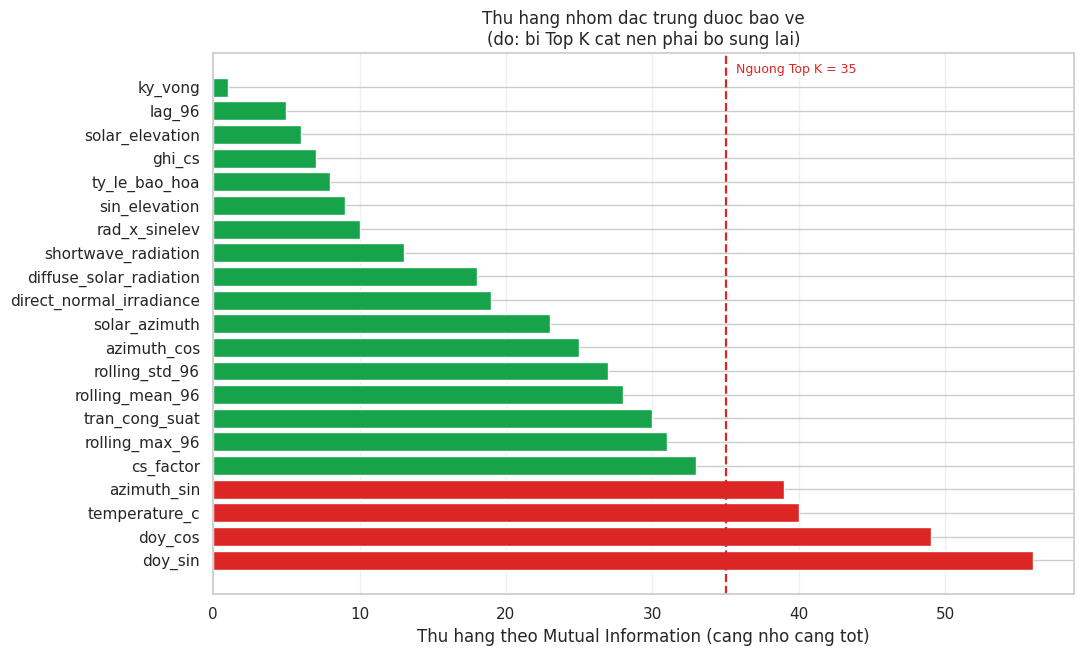

Trong nhom bao ve, 4/21 dac trung nam ngoai Top 35.


In [8]:
_rank = df_merged.reset_index(drop=True).copy()
_rank['thu_hang'] = _rank.index + 1
_bv = _rank[_rank['feature'].isin(BAO_VE)][['thu_hang', 'feature', 'mi_score']].copy() \
    if 'mi_score' in _rank.columns else _rank[_rank['feature'].isin(BAO_VE)][['thu_hang', 'feature']].copy()
_bv['bi_top_k_cat'] = _bv['thu_hang'] > TOP_K_FEATURES

print("--- THU HANG CUA NHOM DAC TRUNG DUOC BAO VE ---")
display(_bv.sort_values('thu_hang'))

fig, ax = plt.subplots(figsize=(11, max(4, 0.32 * len(_bv))))
_col = ['#dc2626' if v else '#16a34a' for v in _bv.sort_values('thu_hang')['bi_top_k_cat']]
_p = _bv.sort_values('thu_hang')
ax.barh(_p['feature'], _p['thu_hang'], color=_col)
ax.axvline(TOP_K_FEATURES, color='#dc2626', ls='--', lw=1.6)
ax.text(TOP_K_FEATURES * 1.02, -0.6, f'Nguong Top K = {TOP_K_FEATURES}', color='#dc2626', fontsize=9)
ax.set_xlabel('Thu hang theo Mutual Information (cang nho cang tot)')
ax.set_title('Thu hang nhom dac trung duoc bao ve\n(do: bi Top K cat nen phai bo sung lai)', fontsize=12)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"Trong nhom bao ve, {int(_bv['bi_top_k_cat'].sum())}/{len(_bv)} dac trung nam ngoai Top {TOP_K_FEATURES}.")


### Nhận xét về danh sách bảo vệ

Các đặc trưng điện mặt trời tương quan mạnh với nhau nên Mutual Information dễ xếp chúng thấp — nhưng
mô hình cây chịu được cộng tuyến, và cần đủ cả nhóm để dựng lại nhịp trong ngày. Vì vậy chúng được bổ
sung lại sau khi cắt Top K, thay vì nâng `TOP_K_FEATURES` lên và kéo theo nhiều đặc trưng nhiễu.


## 8. Trực quan hóa top feature (bar chart)
Vẽ biểu đồ cột thể hiện điểm Mutual Information của Top 35 đặc trưng được lựa chọn.

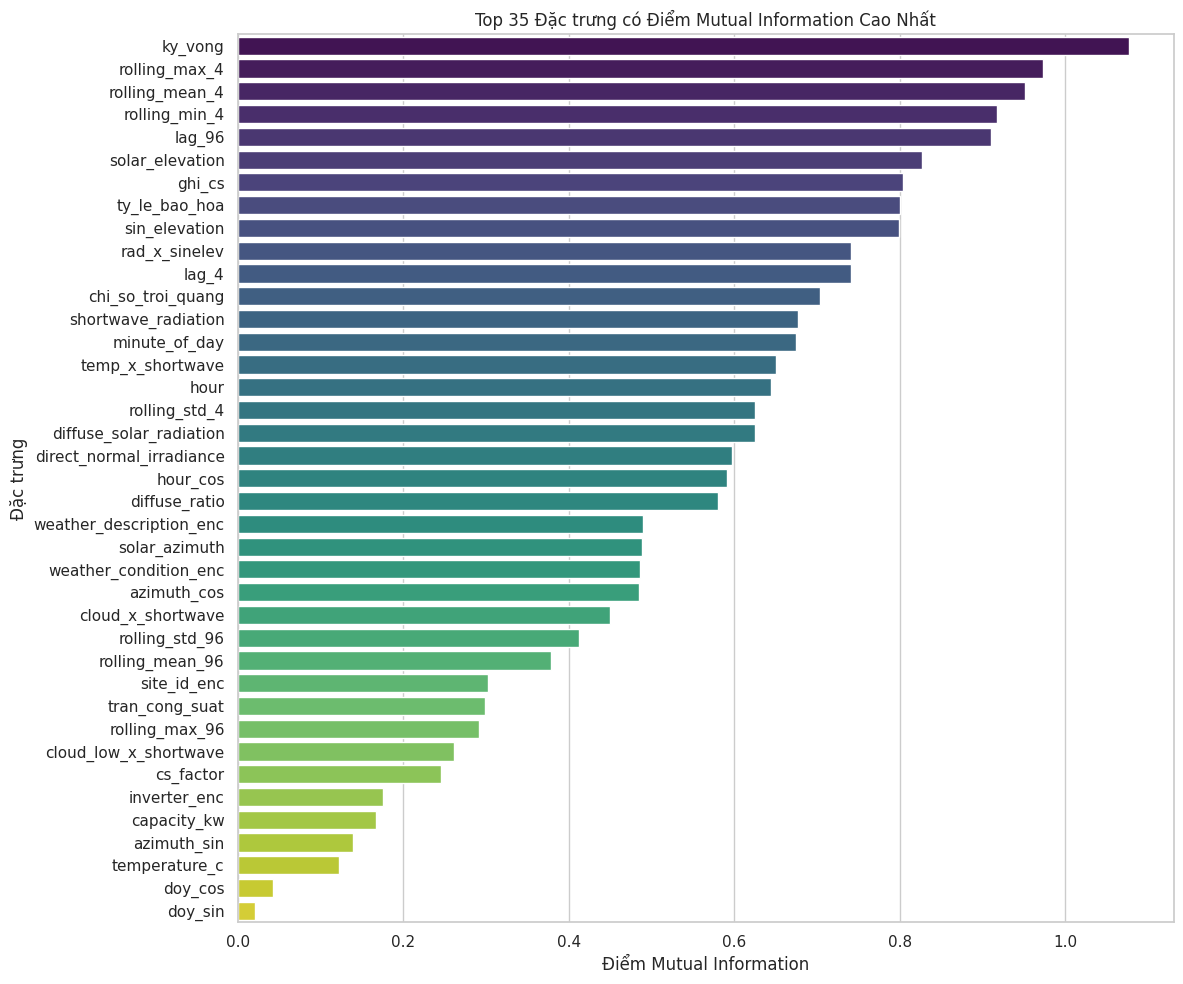

Đã hiển thị biểu đồ Bar Chart Top 35 đặc trưng được chọn.


In [9]:
plt.figure(figsize=(12, 10))
sns.barplot(data=selected_top_k, x='mi_score', y='feature', palette='viridis')
plt.title(f"Top {TOP_K_FEATURES} Đặc trưng có Điểm Mutual Information Cao Nhất")
plt.xlabel("Điểm Mutual Information")
plt.ylabel("Đặc trưng")
plt.tight_layout()
plt.show()
print(f"Đã hiển thị biểu đồ Bar Chart Top {TOP_K_FEATURES} đặc trưng được chọn.")

### Nhận xét và Kết luận:
- **Các đặc trưng đứng đầu**: Bức xạ ngắn (`shortwave_radiation`), tương tác nhiệt bức xạ (`temp_x_radiation`), và các đặc trưng độ trễ gần (`lag_1`, `rolling_mean_1h`) mang điểm Mutual Information cao nhất, hoàn toàn phù hợp với lý thuyết vật lý năng lượng mặt trời.
- **Sự hiện diện của VIF cao**: Một số biến lag/rolling trong Top 35 có chỉ số VIF > 10. Tuy nhiên, theo đúng chiến lược chẩn đoán ở Notebook 06, các biến này được giữ lại vì chúng đóng vai trò quyết định trong việc phản ánh xu hướng thời gian ngắn hạn của công suất phát.

## 9. Export selected_features.json và feature_scores.csv
Xuất danh sách `selected_features.json` chứa Top 35 đặc trưng an toàn và lưu `feature_scores.csv` làm báo cáo cho dự án.

In [10]:
import os

os.makedirs(os.path.dirname(JSON_OUTPUT), exist_ok=True)
os.makedirs(os.path.dirname(CSV_OUTPUT), exist_ok=True)

# 1. Xuất danh sách đặc trưng đã chọn ra file JSON
selected_feature_list = selected_top_k['feature'].tolist()

out_json_payload = {
    'version': 'v5',
    'top_k': TOP_K_FEATURES,
    'selected_features': selected_feature_list,
    'deny_list_count': len(DENY_LIST),
    'bao_ve': _co_bao_ve,
    'bao_ve_bi_top_k_cat': _bi_cat,
    'so_dac_trung_cuoi': len(selected_feature_list),
}

with open(JSON_OUTPUT, 'w', encoding='utf-8') as f:
    json.dump(out_json_payload, f, ensure_ascii=False, indent=2)

# 2. Xuất toàn bộ bảng điểm ra file CSV
df_merged.to_csv(CSV_OUTPUT, index=False)

print(f"Đã xuất danh sách đặc trưng ra: {JSON_OUTPUT}")
print(f"Đã xuất bảng điểm đặc trưng đầy đủ ra: {CSV_OUTPUT}")
print(f"Danh sách {TOP_K_FEATURES} đặc trưng được chọn:")
print(selected_feature_list)
print("Hoàn tất Notebook 07 — Chọn lọc đặc trưng an toàn cho Mô hình!")


Đã xuất danh sách đặc trưng ra: ../../data/model/v5/05_selected/selected_features.json
Đã xuất bảng điểm đặc trưng đầy đủ ra: ../../data/model/v5/05_selected/feature_scores.csv
Danh sách 35 đặc trưng được chọn:
['ky_vong', 'rolling_max_4', 'rolling_mean_4', 'rolling_min_4', 'lag_96', 'solar_elevation', 'ghi_cs', 'ty_le_bao_hoa', 'sin_elevation', 'rad_x_sinelev', 'lag_4', 'chi_so_troi_quang', 'shortwave_radiation', 'minute_of_day', 'temp_x_shortwave', 'hour', 'rolling_std_4', 'diffuse_solar_radiation', 'direct_normal_irradiance', 'hour_cos', 'diffuse_ratio', 'weather_description_enc', 'solar_azimuth', 'weather_condition_enc', 'azimuth_cos', 'cloud_x_shortwave', 'rolling_std_96', 'rolling_mean_96', 'site_id_enc', 'tran_cong_suat', 'rolling_max_96', 'cloud_low_x_shortwave', 'cs_factor', 'inverter_enc', 'capacity_kw', 'azimuth_sin', 'temperature_c', 'doy_cos', 'doy_sin']
Hoàn tất Notebook 07 — Chọn lọc đặc trưng an toàn cho Mô hình!


## 10. Áp danh sách đặc trưng vào dữ liệu (sinh tập sẵn sàng train)

Các mục trên mới chỉ ra **danh sách tên cột**. Bước này cắt thật: lọc mọi tập
(`train`, `val`, `test`, `development` và 10 file fold) theo danh sách đó, ghi ra
`data/model/v5/selected/`.

Ngoài các đặc trưng, giữ thêm vài cột **không phải feature** nhưng bước train cần:
`energy_source`, `exclude_from_training`, `outlier_group` để **lọc dòng** và **khoanh vùng tính metric**,
cùng `site_id` / `timestamp` để nhóm và vẽ biểu đồ.


In [11]:
# Ap danh sach dac trung da chon vao TAT CA cac tap, sinh ra du lieu san sang train.
# Giu lai cac cot ngoai feature can cho buoc train/danh gia:
#   - target                          : de fit va cham diem
#   - site_id, timestamp              : de nhom theo tram va ve theo thoi gian
#   - energy_source, exclude_from_training, outlier_group
#                                     : de LOC DONG va KHOANH VUNG METRIC (khong lam feature)
#   - is_daylight                     : de khoanh vung metric BAN NGAY (khong lam feature)
#   - has_complete_history_features : de loc dong du lich su
FEATURES_DIR = '../../data/model/v5/03_3_features_aggregate'
SELECTED_DIR = '../../data/model/v5/05_selected'

KEEP_EXTRA = [TARGET_COL, SITE_COL, TIMESTAMP_COL,
              'energy_source', 'exclude_from_training', 'outlier_group',
              'has_complete_history_features', 'is_daylight', 'site_scale',
              'pv_clr_lonij']
# is_daylight suy ra tu solar elevation, dua vao feature la ro ri; chi dung de khoanh vung metric. Model da co hour_sin/cos/doy_sin/cos de tu hoc.
# site_scale bi cam lam feature train (DENY_STRUCTURAL_COLLINEAR, cong tuyen voi tran_cong_suat)
# nhung van can giu lai o day vi notebook 06_1 dung no lam MAU SO CHUAN HOA target
# (k = y(T+15) / (site_scale * sin_elevation)), khong phai dau vao mo hinh.

os.makedirs(SELECTED_DIR, exist_ok=True)
os.makedirs(f'{SELECTED_DIR}/time_series_folds', exist_ok=True)

sources = [
    (f'{FEATURES_DIR}/{VERSION}_train_features.parquet',       f'{SELECTED_DIR}/{VERSION}_train_selected.parquet'),
    (f'{FEATURES_DIR}/{VERSION}_val_features.parquet',         f'{SELECTED_DIR}/{VERSION}_val_selected.parquet'),
    (f'{FEATURES_DIR}/{VERSION}_test_features.parquet',        f'{SELECTED_DIR}/{VERSION}_test_selected.parquet'),
    (f'{FEATURES_DIR}/{VERSION}_development_features.parquet', f'{SELECTED_DIR}/{VERSION}_development_selected.parquet'),
]
fold_dir = f'{FEATURES_DIR}/time_series_folds'
if os.path.isdir(fold_dir):
    for name in sorted(os.listdir(fold_dir)):
        if name.endswith('_features.parquet'):
            out_name = name.replace('_features.parquet', '_selected.parquet')
            sources.append((f'{fold_dir}/{name}', f'{SELECTED_DIR}/time_series_folds/{out_name}'))

rows = []
for src, dst in sources:
    if not os.path.exists(src):
        print(f"[CANH BAO] Khong tim thay: {src}")
        continue
    df = pd.read_parquet(src)
    cols_feat = [c for c in selected_feature_list if c in df.columns]
    cols_extra = [c for c in KEEP_EXTRA if c in df.columns and c not in cols_feat]
    missing = [c for c in selected_feature_list if c not in df.columns]
    out = df[cols_feat + cols_extra]
    out.to_parquet(dst, index=False)
    rows.append({
        'tap': os.path.basename(dst).replace('_selected.parquet', ''),
        'dong': len(out),
        'cot_truoc': df.shape[1],
        'cot_sau': out.shape[1],
        'feature': len(cols_feat),
        'cot_phu': len(cols_extra),
        'feature_thieu': len(missing),
    })

df_apply = pd.DataFrame(rows)
print(f"--- DA LOC {len(df_apply)} TAP THEO {len(selected_feature_list)} DAC TRUNG DA CHON ---")
display(df_apply)
if df_apply['feature_thieu'].sum() > 0:
    print("\n[CANH BAO] Co tap thieu dac trung, kiem tra lai notebook 03.")
else:
    print("\nMoi tap deu co du dac trung da chon.")
print(f"Da ghi vao: {SELECTED_DIR}")


--- DA LOC 10 TAP THEO 39 DAC TRUNG DA CHON ---


,tap,dong,cot_truoc,cot_sau,feature,cot_phu,feature_thieu
0,v5_train,1550856,113,49,39,10,0
1,v5_val,723114,113,49,39,10,0
2,v5_test,510468,113,49,39,10,0
3,v5_development,2273970,112,49,39,10,0
4,fold_1_train,233244,114,49,39,10,0
5,fold_1_val,606105,114,49,39,10,0
6,fold_2_train,839349,114,49,39,10,0
7,fold_2_val,711507,114,49,39,10,0
8,fold_3_train,1550856,114,49,39,10,0
9,fold_3_val,723114,114,49,39,10,0



Moi tap deu co du dac trung da chon.
Da ghi vao: ../../data/model/v5/05_selected
